### Manuscript figure generation

**Table 1**

In [1]:
import sys
sys.path.insert(0, "/Users/mromano/research/UCSF-PCNSL")
from pcnsl_data_loader import *
import matplotlib.pyplot as plt

df = load_aws_clinical_imaging_merged()
df.head()

,subject,session,accession,patientdurablekey,Sex,SexualOrientation,BirthDate,Deathdate,PreferredLanguage,FirstRace,SecondRace,Ethnicity,accessions,BiopsyDate,DiagnosisDate,ImageDate,BiopsyDateMinusImageDate,DiagnosisDateMinusImageDate
0,sub-0001,ses-0001,0001,0001,Female,Straight,3/13/73,NaN,English,Other,NaN,Hispanic or Latino,1,NaN,8/26/21,7/21/21,NaN,36
1,sub-0002,ses-0001,0002,0002,Female,Straight,5/23/62,NaN,English,White,NaN,Not Hispanic or Latino,1,1/7/21,1/9/21,1/5/21,2.0,4
2,sub-0003,ses-0001,0003,0003,Female,Straight,2/13/51,NaN,English,White,NaN,Not Hispanic or Latino,1,2/27/22,3/20/22,5/12/21,291.0,312
3,sub-0004,ses-0001,0004,0004,Male,Straight,7/16/67,NaN,English,White,NaN,Not Hispanic or Latino,1,3/22/22,4/10/22,3/16/22,6.0,25
4,sub-0005,ses-0001,0005,0005,Female,Declines to answer,3/17/50,NaN,English,White,NaN,Not Hispanic or Latino,1,6/6/23,6/23/23,6/3/23,3.0,20


In [2]:
from great_tables import GT, md, html
import pandas as pd
import numpy as np

# Prepare data for the summary table
df_summary = df.copy()
dates_df = load_aws_biopsy_and_diagnosis_dates()

# Parse dates and calculate age at diagnosis
def parse_date_with_century(date_str):
    if pd.isna(date_str):
        return pd.NaT
    dt = pd.to_datetime(date_str, format='%m/%d/%y')
    if dt.year > 2025:
        dt = dt.replace(year=dt.year - 100)
    return dt

df_summary['BirthDateParsed'] = df_summary['BirthDate'].apply(parse_date_with_century)
df_summary['DiagnosisDateParsed'] = pd.to_datetime(df_summary['DiagnosisDate'], format='%m/%d/%y')
df_summary['AgeAtDiagnosis'] = (df_summary['DiagnosisDateParsed'] - df_summary['BirthDateParsed']).dt.days / 365.25

# Flip imaging timing so negative = MRI before event
df_summary['ImagingRelativeToDiagnosis'] = -df_summary['DiagnosisDateMinusImageDate']
df_summary['ImagingRelativeToBiopsy'] = -df_summary['BiopsyDateMinusImageDate']

# Total N
total_n = len(df_summary)

# Build summary statistics
summary_rows = []

# --- Age at Diagnosis ---
age_data = df_summary['AgeAtDiagnosis'].dropna()
summary_rows.append({
    'Category': 'Age at Diagnosis',
    'Variable': 'Years, mean \u00b1 SD',
    'Value': f"{age_data.mean():.1f} \u00b1 {age_data.std():.1f}"
})
summary_rows.append({
    'Category': 'Age at Diagnosis',
    'Variable': 'Median (IQR)',
    'Value': f"{age_data.median():.1f} ({age_data.quantile(0.25):.1f}\u2013{age_data.quantile(0.75):.1f})"
})
summary_rows.append({
    'Category': 'Age at Diagnosis',
    'Variable': 'Range',
    'Value': f"{age_data.min():.1f}\u2013{age_data.max():.1f}"
})

# --- Sex ---
sex_counts = df_summary['Sex'].value_counts()
for sex, count in sex_counts.items():
    pct = count / total_n * 100
    summary_rows.append({
        'Category': 'Sex',
        'Variable': sex,
        'Value': f"{count} ({pct:.1f}%)"
    })

# --- Race ---
race_counts = df_summary['FirstRace'].value_counts()
for race, count in race_counts.items():
    pct = count / total_n * 100
    summary_rows.append({
        'Category': 'Race',
        'Variable': race,
        'Value': f"{count} ({pct:.1f}%)"
    })

# --- Ethnicity ---
ethnicity_counts = df_summary['Ethnicity'].value_counts()
for ethnicity, count in ethnicity_counts.items():
    pct = count / total_n * 100
    # Shorten label
    eth_label = ethnicity.replace('Not Hispanic or Latino', 'Not Hispanic/Latino').replace('Hispanic or Latino', 'Hispanic/Latino')
    summary_rows.append({
        'Category': 'Ethnicity',
        'Variable': eth_label,
        'Value': f"{count} ({pct:.1f}%)"
    })

# --- Survival / Vital Status ---
demo_df = load_aws_demographics()
demo_df['patientdurablekey'] = demo_df['patientdurablekey'].astype(str).str.zfill(4)
dates_df['patientdurablekey'] = dates_df['patientdurablekey'].astype(str).str.zfill(4)

demo_df['Deathdate'] = pd.to_datetime(demo_df['Deathdate'], format='%m/%d/%y', errors='coerce')
# Fix century for death dates parsed as future
demo_df.loc[demo_df['Deathdate'].dt.year > 2025, 'Deathdate'] = (
    demo_df.loc[demo_df['Deathdate'].dt.year > 2025, 'Deathdate']
    .apply(lambda x: x.replace(year=x.year - 100))
)
dates_df['DiagnosisDateParsed'] = pd.to_datetime(dates_df['DiagnosisDate'], format='%m/%d/%y', errors='coerce')

# Get earliest diagnosis date per patient
dx_df = dates_df.groupby('patientdurablekey', as_index=False).agg(
    diagnosis_date=('DiagnosisDateParsed', 'min')
)

# Merge with death dates (one row per patient)
surv_df = dx_df.merge(
    demo_df[['patientdurablekey', 'Deathdate']].drop_duplicates(),
    on='patientdurablekey',
    how='left'
)

surv_df['event'] = surv_df['Deathdate'].notna().astype(int)
surv_df['time_days'] = (surv_df['Deathdate'] - surv_df['diagnosis_date']).dt.days

# For alive/censored patients, use today as last follow-up
last_followup = pd.Timestamp.today()
surv_df.loc[surv_df['event'] == 0, 'time_days'] = (
    last_followup - surv_df.loc[surv_df['event'] == 0, 'diagnosis_date']
).dt.days

surv_df = surv_df[surv_df['time_days'] >= 0]
surv_df['time_months'] = surv_df['time_days'] / 30.44

n_deceased = surv_df['event'].sum()
n_alive = (surv_df['event'] == 0).sum()
n_surv = len(surv_df)

summary_rows.append({
    'Category': 'Vital Status',
    'Variable': 'Deceased, n (%)',
    'Value': f"{n_deceased} ({n_deceased/n_surv*100:.1f}%)"
})
summary_rows.append({
    'Category': 'Vital Status',
    'Variable': 'Alive/Censored, n (%)',
    'Value': f"{n_alive} ({n_alive/n_surv*100:.1f}%)"
})

# Follow-up time (all patients)
fu_months = surv_df['time_months']
summary_rows.append({
    'Category': 'Follow-up Time',
    'Variable': 'Months, median (IQR)',
    'Value': f"{fu_months.median():.1f} ({fu_months.quantile(0.25):.1f}\u2013{fu_months.quantile(0.75):.1f})"
})
summary_rows.append({
    'Category': 'Follow-up Time',
    'Variable': 'Range',
    'Value': f"{fu_months.min():.1f}\u2013{fu_months.max():.1f}"
})

# Survival time among deceased
deceased_months = surv_df.loc[surv_df['event'] == 1, 'time_months']
summary_rows.append({
    'Category': 'Survival Time (Deceased)',
    'Variable': 'Months, median (IQR)',
    'Value': f"{deceased_months.median():.1f} ({deceased_months.quantile(0.25):.1f}\u2013{deceased_months.quantile(0.75):.1f})"
})
summary_rows.append({
    'Category': 'Survival Time (Deceased)',
    'Variable': 'Range',
    'Value': f"{deceased_months.min():.1f}\u2013{deceased_months.max():.1f}"
})

# --- Imaging Timing Relative to Diagnosis ---
dx_timing = df_summary['ImagingRelativeToDiagnosis'].dropna()
n_before_or_on_dx = (dx_timing <= 0).sum()
n_after_dx = (dx_timing > 0).sum()
summary_rows.append({
    'Category': 'MRI Timing Relative to Diagnosis',
    'Variable': 'MRI before or on diagnosis, n (%)',
    'Value': f"{n_before_or_on_dx} ({n_before_or_on_dx/len(dx_timing)*100:.1f}%)"
})
summary_rows.append({
    'Category': 'MRI Timing Relative to Diagnosis',
    'Variable': 'MRI after diagnosis, n (%)',
    'Value': f"{n_after_dx} ({n_after_dx/len(dx_timing)*100:.1f}%)"
})
summary_rows.append({
    'Category': 'MRI Timing Relative to Diagnosis',
    'Variable': 'Days, median (IQR)',
    'Value': f"{dx_timing.median():.0f} ({dx_timing.quantile(0.25):.0f} to {dx_timing.quantile(0.75):.0f})"
})
summary_rows.append({
    'Category': 'MRI Timing Relative to Diagnosis',
    'Variable': 'Range',
    'Value': f"{dx_timing.min():.0f} to {dx_timing.max():.0f}"
})

# --- Imaging Timing Relative to Biopsy ---
bx_timing = df_summary['ImagingRelativeToBiopsy'].dropna()
n_before_or_on_bx = (bx_timing <= 0).sum()
n_after_bx = (bx_timing > 0).sum()
summary_rows.append({
    'Category': 'MRI Timing Relative to Biopsy',
    'Variable': 'MRI before or on biopsy, n (%)',
    'Value': f"{n_before_or_on_bx} ({n_before_or_on_bx/len(bx_timing)*100:.1f}%)"
})
summary_rows.append({
    'Category': 'MRI Timing Relative to Biopsy',
    'Variable': 'MRI after biopsy, n (%)',
    'Value': f"{n_after_bx} ({n_after_bx/len(bx_timing)*100:.1f}%)"
})
summary_rows.append({
    'Category': 'MRI Timing Relative to Biopsy',
    'Variable': 'Days, median (IQR)',
    'Value': f"{bx_timing.median():.0f} ({bx_timing.quantile(0.25):.0f} to {bx_timing.quantile(0.75):.0f})"
})
summary_rows.append({
    'Category': 'MRI Timing Relative to Biopsy',
    'Variable': 'Range',
    'Value': f"{bx_timing.min():.0f} to {bx_timing.max():.0f}"
})

# Create DataFrame
summary_df = pd.DataFrame(summary_rows)

# Create great_tables table
table1 = (
    GT(summary_df, rowname_col="Variable", groupname_col="Category")
    .tab_header(
        title="Table 1. Patient Demographics and Clinical Characteristics",
        subtitle=f"N = {total_n}"
    )
    .tab_stubhead(label="Characteristic")
    .cols_label(Value="n (%) or Summary Statistic")
    .cols_align(align="left", columns="Value")
    .tab_source_note(
        source_note="IQR = interquartile range. MRI timing is calculated as MRI date minus event date (negative = MRI before event). Follow-up time for alive/censored patients calculated to current date."
    )
    .opt_horizontal_padding(scale=2)
    .opt_vertical_padding(scale=1.5)
)

table1

# Save as HTML (can be opened in Word and converted to docx)
with open("table1.html", "w") as f:
    f.write(table1.as_raw_html())
print("Table saved to table1.html")

Table saved to table1.html


**Table 2 -- genetic summaries**

In [3]:
from great_tables import GT, md, html

genes_df = load_aws_mutations()

# Get unique patients per gene
patients_per_gene = genes_df.groupby('gene')['patientdurablekey'].nunique()

# Sort by number of patients and get top 10
top_10_genes = patients_per_gene.sort_values(ascending=False).head(10)

# Get total unique patients in cohort
total_patients = genes_df['patientdurablekey'].nunique()

# Build table data
table_rows = []

for rank, (gene, patient_count) in enumerate(top_10_genes.items(), 1):
    percentage = (patient_count / total_patients) * 100
    
    # Find top 3 alterations for this gene
    gene_data = genes_df[genes_df['gene'] == gene]
    top_3_alterations = gene_data.groupby(['hgvsp', 'hgvsc']).size().sort_values(ascending=False).head(3)
    
    # Format top alterations as a string
    alt_strings = []
    for (hgvsp, hgvsc), count in top_3_alterations.items():
        if pd.notna(hgvsp) and hgvsp != '':
            alt_strings.append(f"{hgvsp} (n={count})")
        elif pd.notna(hgvsc) and hgvsc != '':
            alt_strings.append(f"{hgvsc} (n={count})")
    
    top_alterations_str = "; ".join(alt_strings) if alt_strings else "—"
    
    table_rows.append({
        'Rank': rank,
        'Gene': gene,
        'Patients': f"{patient_count}/{total_patients}",
        'Frequency': f"{percentage:.1f}%",
        'Top Alterations': top_alterations_str
    })

# Create DataFrame
genes_table_df = pd.DataFrame(table_rows)

# Create great_tables table
genes_table = (
    GT(genes_table_df)
    .tab_header(
        title="Table 2. Top 10 Most Commonly Mutated Genes",
        subtitle=f"N = {total_patients} patients with mutation data"
    )
    .cols_label(
        Rank="Rank",
        Gene="Gene",
        Patients="n/N",
        Frequency="Frequency",
        **{"Top Alterations": "Most Common Alterations"}
    )
    .cols_align(align="center", columns=["Rank", "Patients", "Frequency"])
    .cols_align(align="left", columns=["Gene", "Top Alterations"])
    .tab_source_note(
        source_note="Alterations shown are protein-level changes (HGVSp notation) with counts in parentheses."
    )
    .opt_horizontal_padding(scale=2)
    .opt_vertical_padding(scale=1.5)
)

genes_table

# Save as HTML (can be opened in Word and converted to docx)
with open("table2.html", "w") as f:
    f.write(genes_table.as_raw_html())
print("Table saved to table2.html")

Table saved to table2.html


**Fig 1. Summary statistics for lesions**

In [4]:
import tqdm


def aggregate_multisequence_lesion_data(base_folder):
    """
    Aggregate FLAIR and T1Post lesion data from:
    - sub-*/ses-*/statistics/lesions_SummaryLesions/ (summary files)
    - sub-*/ses-*/statistics/lesions_radiomics/ (radiomics files)
    Creates one combined table with suffixed column names.
    
    Parameters:
    - base_folder: Path to the derivatives/pyalfe folder containing sub-* folders
    
    Returns:
    - aggregated_df: Combined DataFrame with all lesion data
    """
    
    all_records = []
    
    # Iterate through each subject folder (sub-*)
    for subject_folder in tqdm.tqdm(sorted(Path(base_folder).glob('sub-*'))):
        if subject_folder.is_dir():
            subject_id = subject_folder.name
            
            # Iterate through each session folder (ses-*)
            for session_folder in sorted(subject_folder.glob('ses-*')):
                if session_folder.is_dir():
                    session_id = session_folder.name
                    
                    # Initialize record for this subject-session
                    record = {
                        'subject_id': subject_id,
                        'session_id': session_id
                    }
                    
                    # Track if any data was found for this subject-session
                    found_any_data = False
                    
                    # Define file locations to process
                    file_configs = [
                        {
                            'name': 'SummaryLesions',
                            'folder': session_folder / 'statistics' / 'lesions_SummaryLesions',
                            'pattern': '{subject_id}_{session_id}_{sequence}_SummaryLesions.*'
                        },
                        {
                            'name': 'Radiomics',
                            'folder': session_folder / 'statistics' / 'lesions_radiomics',
                            'pattern': '{subject_id}_{session_id}_{sequence}_radiomics.*'
                        }
                    ]
                    
                    # Define sequences to process
                    sequences = ['FLAIR', 'T1Post']
                    
                    # Process each file type and sequence
                    for config in file_configs:
                        folder_path = config['folder']
                        file_type = config['name']
                        
                        if not folder_path.exists():
                            print(f"{file_type} folder not found: {subject_id}/{session_id}")
                            continue
                        
                        for sequence in sequences:
                            # Construct filename pattern
                            pattern = config['pattern'].format(
                                subject_id=subject_id,
                                session_id=session_id,
                                sequence=sequence
                            )
                            matching_files = list(folder_path.glob(pattern))
                            
                            if matching_files:
                                file_path = matching_files[0]  # Take first match
                                
                                try:
                                    # Read file based on extension
                                    if file_path.suffix == '.csv':
                                        df = pd.read_csv(file_path)
                                    elif file_path.suffix in ['.xlsx', '.xls']:
                                        df = pd.read_excel(file_path)
                                    elif file_path.suffix == '.txt':
                                        df = pd.read_csv(file_path, sep='\t')
                                    else:
                                        print(f"Unsupported file type: {file_path}")
                                        continue
                                    
                                    # Check if data is in vertical format (2 columns: variable names and values)
                                    if df.shape[1] == 2:
                                        # Vertical format - transpose it
                                        # First column = variable names, second column = values
                                        var_col = df.columns[0]
                                        val_col = df.columns[1]
                                        
                                        for idx, row in df.iterrows():
                                            var_name = str(row[var_col])
                                            var_value = row[val_col]
                                            new_col_name = f"{var_name}_{sequence}"
                                            record[new_col_name] = var_value
                                        
                                        found_any_data = True
                                    else:
                                        # Horizontal format - use as-is
                                        if len(df) > 0:
                                            row_data = df.iloc[0]
                                            
                                            for col in df.columns:
                                                new_col_name = f"{col}_{sequence}"
                                                record[new_col_name] = row_data[col]
                                        
                                        found_any_data = True
                                    
                                except Exception as e:
                                    print(f"Error reading {file_path}: {e}")
                            else:
                                print(f"File not found: {subject_id}/{session_id}/{file_type}/{sequence}")
                    
                    # Add record for every subject-session, even if some files are missing
                    all_records.append(record)
    
    # Create DataFrame from all records
    if all_records:
        aggregated_df = pd.DataFrame(all_records)
        
        # Fill missing values with "N/A"
        aggregated_df = aggregated_df.fillna("N/A")
        
        print(f"\n{'='*60}")
        print(f"Aggregation complete!")
        print(f"Total records: {len(aggregated_df)}")
        print(f"Total columns: {len(aggregated_df.columns)}")
        print(f"{'='*60}")
        return aggregated_df
    else:
        print("No data found!")
        return pd.DataFrame()


# Aggregate lesion files from the derivatives/pyalfe directory
if __name__ == "__main__":
    dropbox_path = "/Users/mromano/Library/CloudStorage/Box-Box/Research/pcnsl_radiomics/dataset_manuscript/bids_dir_for_aws_anon/derivatives/pyalfe/"
    
    # Aggregate lesion files
    combined_data = aggregate_multisequence_lesion_data(dropbox_path)
    
    # Display summary
    if not combined_data.empty:
        
        print(f"\nData shape: {combined_data.shape}")
        
        print("\nMissing data summary:")
        missing = combined_data.isnull().sum()
        if missing.any():
            print(missing[missing > 0])
        else:
            print("No missing data!")
        
        # Save aggregated data
        output_file = "combined_lesion_data.csv"
        combined_data.to_csv(output_file, index=False)
        print(f"\nAggregated data saved to: {output_file}")

100%|██████████| 150/150 [00:00<00:00, 251.33it/s]



Aggregation complete!
Total records: 150
Total columns: 238

Data shape: (150, 238)

Missing data summary:
No missing data!

Aggregated data saved to: combined_lesion_data.csv


In [5]:
[print(x) for x in combined_data.columns]

subject_id
session_id
total_lesion_volume_FLAIR
lesion_volume_in_background_FLAIR
lesion_volume_in_csf_FLAIR
lesion_volume_in_cortical_gray_matter_FLAIR
lesion_volume_in_white_matter_FLAIR
lesion_volume_in_deep_gray_matter_FLAIR
lesion_volume_in_brain_stem_FLAIR
lesion_volume_in_cerebellum_FLAIR
relative_T1_signal_FLAIR
relative_T1Post_signal_FLAIR
relative_FLAIR_signal_FLAIR
relative_ADC_signal_FLAIR
relative_min_ADC_signal_FLAIR
min_ADC_signal_FLAIR
mean_ADC_signal_FLAIR
median_ADC_signal_FLAIR
five_percentile_ADC_signal_FLAIR
ninety_five_percentile_ADC_signal_FLAIR
enhancement_FLAIR
average_dist_to_ventricles_(voxels)_FLAIR
minimum_dist_to_Ventricles_(voxels)_FLAIR
lesion_volume_in_Frontal_FLAIR
percentage_volume_in_Frontal_FLAIR
lesion_volume_in_Parietal_FLAIR
percentage_volume_in_Parietal_FLAIR
lesion_volume_in_Occipital_FLAIR
percentage_volume_in_Occipital_FLAIR
lesion_volume_in_Temporal_FLAIR
percentage_volume_in_Temporal_FLAIR
lesion_volume_in_AnteriorTemporal_FLAIR
percentage_

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [6]:
# Define variables of interest
key_variables = [
        "total_lesion_volume",
        "number_of_lesions",
        "original_firstorder_Kurtosis",
        "original_firstorder_Entropy",
        "original_firstorder_Energy",
        "relative_ADC_signal",
        "relative_T1_signal",
        "relative_T1Post_signal", 
        "relative_FLAIR_signal",
        "percentage_volume_in_White Matter",
        "percentage_volume_in_Cortical Gray Matter",
        "percentage_volume_in_Deep Gray Matter",
        "percentage_volume_in_Frontal",
        "percentage_volume_in_Parietal",
        "percentage_volume_in_Occipital",
        "percentage_volume_in_Temporal",
        "percentage_volume_in_CorpusCallosum",
        "percentage_volume_in_Cerebellum",
        "percentage_volume_in_Brain Stem"
]

# Get FLAIR and T1post variables
flair_vars = [f'{var}_FLAIR' for var in key_variables]
t1post_vars = [f'{var}_T1Post' for var in key_variables]

df = combined_data.copy()

/var/folders/ld/60ss44qj6214f09pm2h476dh0000gn/T/ipykernel_77530/727314055.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data_vol, x='Sequence', y='value', palette=COLORS, ax=ax_volume,
/var/folders/ld/60ss44qj6214f09pm2h476dh0000gn/T/ipykernel_77530/727314055.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data_count, x='Sequence', y='value', palette=COLORS, ax=ax_count,
/var/folders/ld/60ss44qj6214f09pm2h476dh0000gn/T/ipykernel_77530/727314055.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data_kurt, 

Computing bootstrapped confidence intervals...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved to fig2_lesion_comparison.png and fig2_lesion_comparison.eps


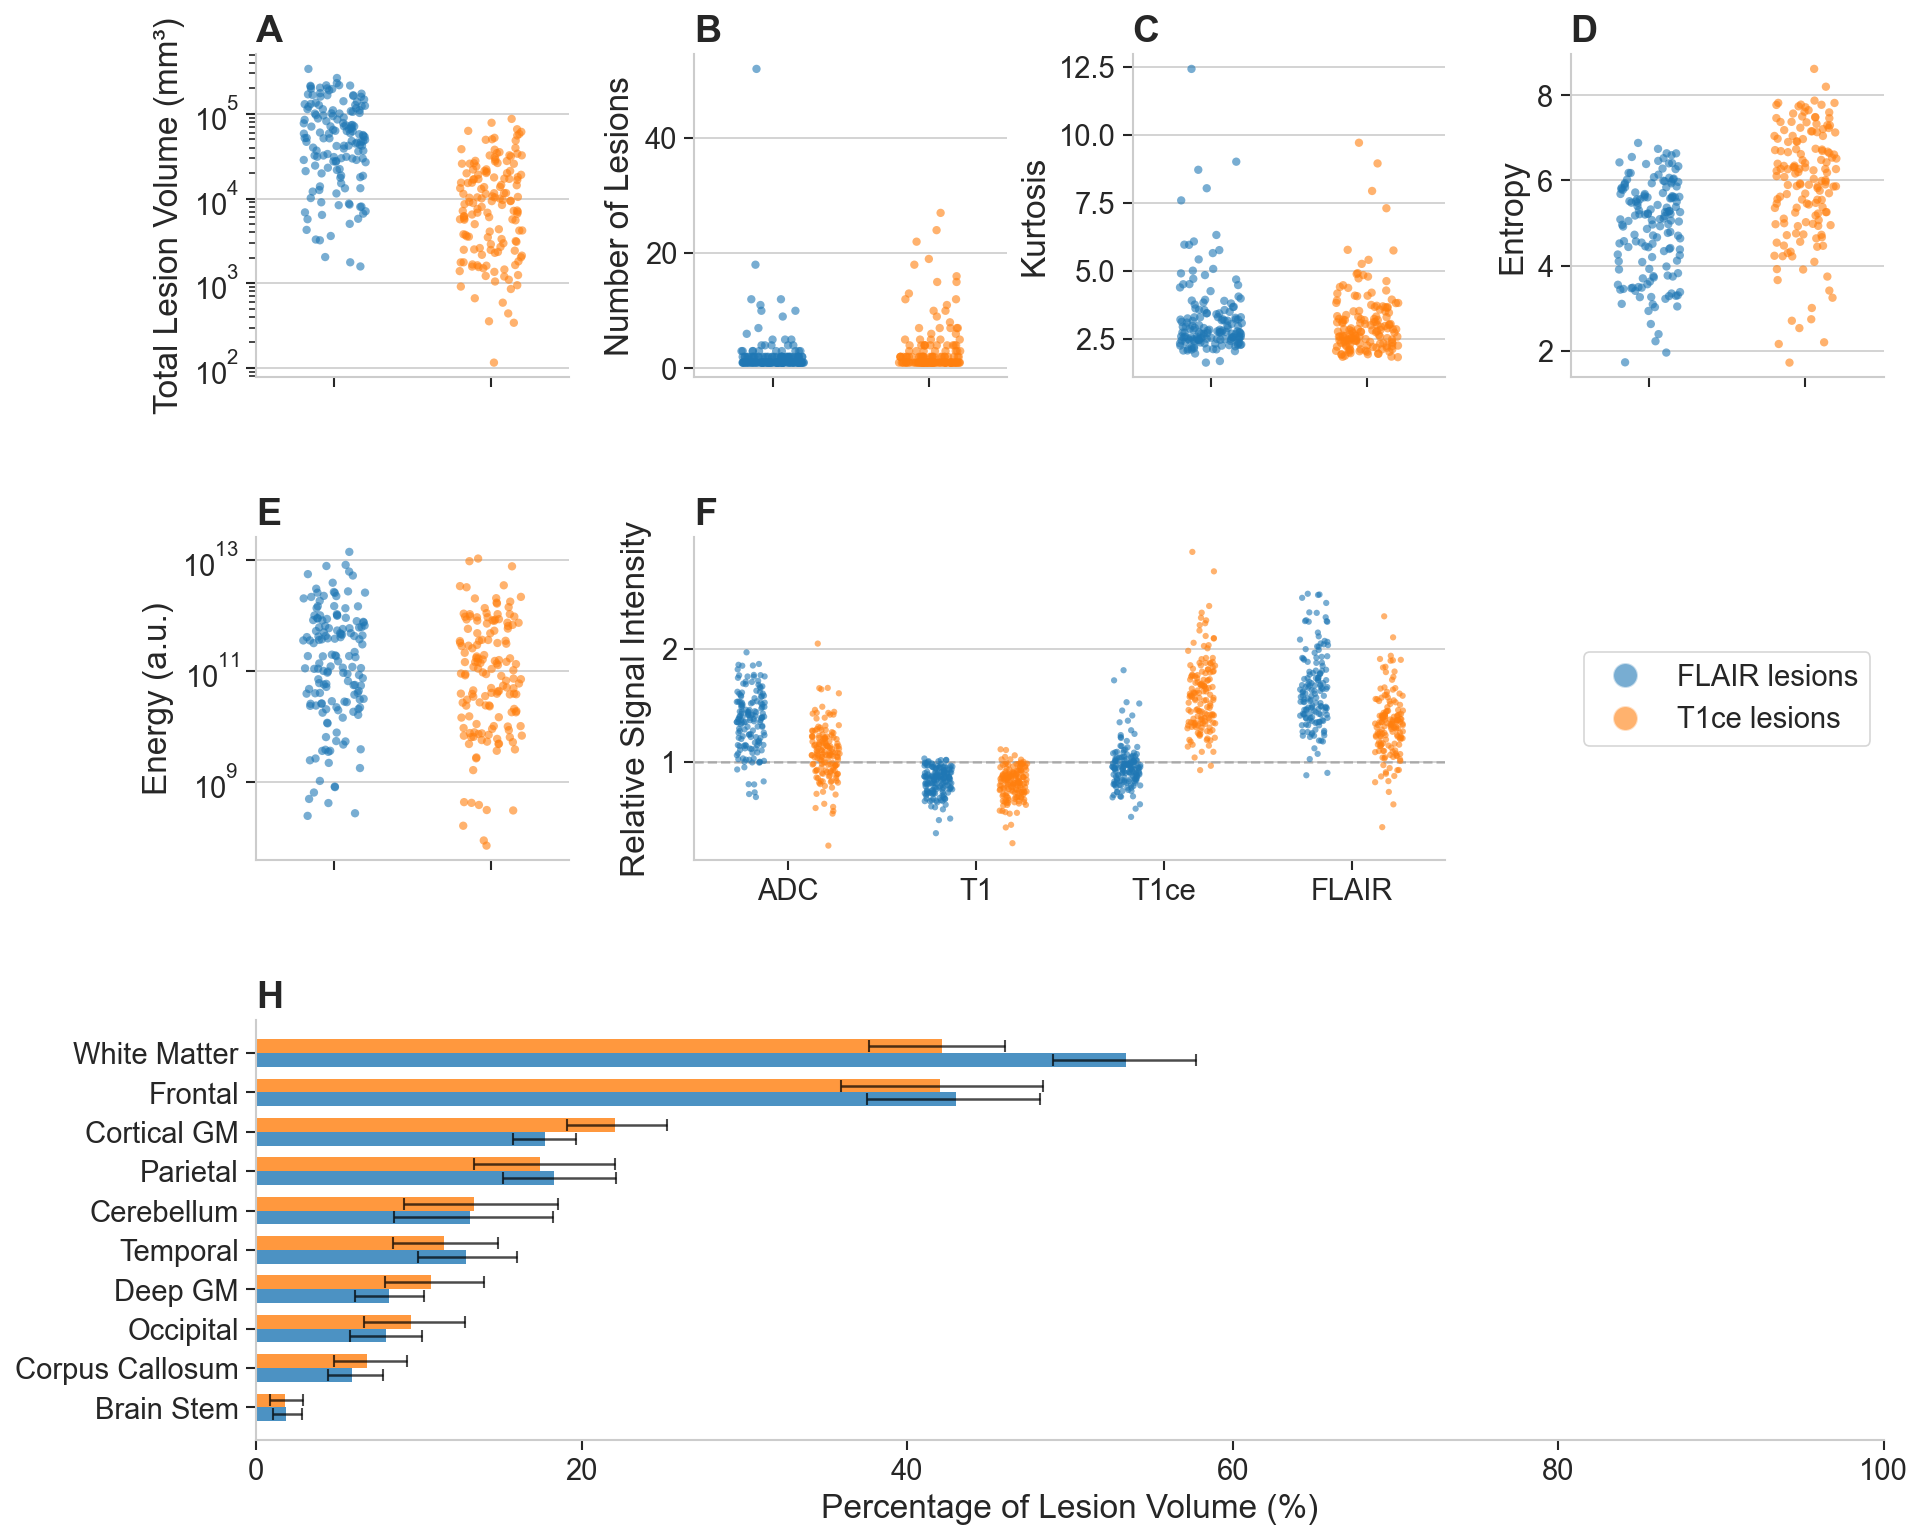

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# Set publication-quality style with larger fonts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.6)
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

# Color scheme matching existing figures
COLORS = {'FLAIR': '#1f77b4', 'T1ce': '#ff7f0e'}

def bootstrap_ci(data, n_bootstrap=1000, ci=95, statistic=np.mean):
    """Calculate bootstrapped confidence interval for a statistic."""
    data = data[~np.isnan(data)]
    if len(data) < 2:
        return 0, 0
    
    boot_stats = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_stats.append(statistic(sample))
    
    lower = np.percentile(boot_stats, (100 - ci) / 2)
    upper = np.percentile(boot_stats, 100 - (100 - ci) / 2)
    return lower, upper

# Prepare data for plotting - melt to long format
def prepare_plot_data(df, var_name):
    """Prepare data in long format for strip plots."""
    flair_col = f'{var_name}_FLAIR'
    t1post_col = f'{var_name}_T1Post'
    
    flair_vals = pd.to_numeric(df[flair_col], errors='coerce').values
    t1post_vals = pd.to_numeric(df[t1post_col], errors='coerce').values
    
    data = pd.DataFrame({
        'value': np.concatenate([flair_vals, t1post_vals]),
        'Sequence': ['FLAIR']*len(flair_vals) + ['T1ce']*len(t1post_vals)
    })
    return data, flair_vals, t1post_vals

# Create figure with GridSpec
fig = plt.figure(figsize=(14, 12), dpi=150)
gs = gridspec.GridSpec(3, 4, height_ratios=[1, 1, 1.3], hspace=0.45, wspace=0.4)

# ============================================================================
# ROW 1: Lesion Burden + First-Order Radiomics (Panels A-D)
# ============================================================================

# Panel A: Total Lesion Volume (log scale)
ax_volume = fig.add_subplot(gs[0, 0])
data_vol, flair_vol, t1post_vol = prepare_plot_data(df, 'total_lesion_volume')
sns.stripplot(data=data_vol, x='Sequence', y='value', palette=COLORS, ax=ax_volume, 
              alpha=0.6, jitter=0.2, size=4)
ax_volume.set_yscale('log')
ax_volume.set_ylabel('Total Lesion Volume (mm³)')
ax_volume.set_xlabel('')
ax_volume.set_xticklabels([])  # Remove x-axis labels (use legend instead)
ax_volume.set_title('A', loc='left', fontweight='bold', fontsize=18)
ax_volume.spines['top'].set_visible(False)
ax_volume.spines['right'].set_visible(False)

# Panel B: Number of Lesions
ax_count = fig.add_subplot(gs[0, 1])
data_count, flair_count, t1post_count = prepare_plot_data(df, 'number_of_lesions')
sns.stripplot(data=data_count, x='Sequence', y='value', palette=COLORS, ax=ax_count,
              alpha=0.6, jitter=0.2, size=4)
ax_count.set_ylabel('Number of Lesions')
ax_count.set_xlabel('')
ax_count.set_xticklabels([])  # Remove x-axis labels (use legend instead)
ax_count.set_title('B', loc='left', fontweight='bold', fontsize=18)
ax_count.spines['top'].set_visible(False)
ax_count.spines['right'].set_visible(False)

# Panel C: Kurtosis
ax_kurtosis = fig.add_subplot(gs[0, 2])
data_kurt, flair_kurt, t1post_kurt = prepare_plot_data(df, 'original_firstorder_Kurtosis')
sns.stripplot(data=data_kurt, x='Sequence', y='value', palette=COLORS, ax=ax_kurtosis,
              alpha=0.6, jitter=0.2, size=4)
ax_kurtosis.set_ylabel('Kurtosis')
ax_kurtosis.set_xlabel('')
ax_kurtosis.set_xticklabels([])  # Remove x-axis labels (use legend instead)
ax_kurtosis.set_title('C', loc='left', fontweight='bold', fontsize=18)
ax_kurtosis.spines['top'].set_visible(False)
ax_kurtosis.spines['right'].set_visible(False)

# Panel D: Entropy
ax_entropy = fig.add_subplot(gs[0, 3])
data_ent, flair_ent, t1post_ent = prepare_plot_data(df, 'original_firstorder_Entropy')
sns.stripplot(data=data_ent, x='Sequence', y='value', palette=COLORS, ax=ax_entropy,
              alpha=0.6, jitter=0.2, size=4)
ax_entropy.set_ylabel('Entropy')
ax_entropy.set_xlabel('')
ax_entropy.set_xticklabels([])  # Remove x-axis labels (use legend instead)
ax_entropy.set_title('D', loc='left', fontweight='bold', fontsize=18)
ax_entropy.spines['top'].set_visible(False)
ax_entropy.spines['right'].set_visible(False)

# ============================================================================
# ROW 2: Energy + Relative Signals (Panels E-G)
# ============================================================================

# Panel E: Energy (log scale)
ax_energy = fig.add_subplot(gs[1, 0])
data_energy, flair_energy, t1post_energy = prepare_plot_data(df, 'original_firstorder_Energy')
sns.stripplot(data=data_energy, x='Sequence', y='value', palette=COLORS, ax=ax_energy,
              alpha=0.6, jitter=0.2, size=4)
ax_energy.set_yscale('log')
ax_energy.set_ylabel('Energy (a.u.)')
ax_energy.set_xlabel('')
ax_energy.set_xticklabels([])  # Remove x-axis labels (use legend instead)
ax_energy.set_title('E', loc='left', fontweight='bold', fontsize=18)
ax_energy.spines['top'].set_visible(False)
ax_energy.spines['right'].set_visible(False)

# Panel F: Relative Signals (grouped strip plot - spans 2 columns)
ax_signals = fig.add_subplot(gs[1, 1:3])

# Prepare data for all 4 relative signals
signal_vars = ['relative_ADC_signal', 'relative_T1_signal', 'relative_T1Post_signal', 'relative_FLAIR_signal']
signal_labels = ['ADC', 'T1', 'T1ce', 'FLAIR']

signal_data_list = []
for var, label in zip(signal_vars, signal_labels):
    flair_col = f'{var}_FLAIR'
    t1post_col = f'{var}_T1Post'
    
    flair_vals = pd.to_numeric(df[flair_col], errors='coerce').values
    t1post_vals = pd.to_numeric(df[t1post_col], errors='coerce').values
    
    for val in flair_vals:
        signal_data_list.append({'Signal Type': label, 'Sequence': 'FLAIR', 'value': val})
    for val in t1post_vals:
        signal_data_list.append({'Signal Type': label, 'Sequence': 'T1ce', 'value': val})

signal_df = pd.DataFrame(signal_data_list)
sns.stripplot(data=signal_df, x='Signal Type', y='value', hue='Sequence', 
              palette=COLORS, ax=ax_signals, alpha=0.6, dodge=True, jitter=0.15, size=3, legend=False)
ax_signals.set_ylabel('Relative Signal Intensity')
ax_signals.set_xlabel('')
ax_signals.set_title('F', loc='left', fontweight='bold', fontsize=18)
ax_signals.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax_signals.spines['top'].set_visible(False)
ax_signals.spines['right'].set_visible(False)

# Panel G: Legend (single unified legend)
ax_legend = fig.add_subplot(gs[1, 3])
ax_legend.axis('off')

# Create unified legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['FLAIR'], 
               markersize=12, label='FLAIR lesions', alpha=0.6),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['T1ce'], 
               markersize=12, label='T1ce lesions', alpha=0.6),
]
ax_legend.legend(handles=legend_elements, loc='center', fontsize=14, frameon=True)

# ============================================================================
# ROW 3: Anatomical Distribution (Panel H - full width)
# ============================================================================

ax_anatomy = fig.add_subplot(gs[2, :])

# Define anatomical regions in order of magnitude
anatomy_vars = [
    ('percentage_volume_in_White Matter', 'White Matter'),
    ('percentage_volume_in_Frontal', 'Frontal'),
    ('percentage_volume_in_Cortical Gray Matter', 'Cortical GM'),
    ('percentage_volume_in_Parietal', 'Parietal'),
    ('percentage_volume_in_Cerebellum', 'Cerebellum'),
    ('percentage_volume_in_Temporal', 'Temporal'),
    ('percentage_volume_in_Deep Gray Matter', 'Deep GM'),
    ('percentage_volume_in_Occipital', 'Occipital'),
    ('percentage_volume_in_CorpusCallosum', 'Corpus Callosum'),
    ('percentage_volume_in_Brain Stem', 'Brain Stem'),
]

# Calculate means and bootstrapped 95% CI for bar chart
print("Computing bootstrapped confidence intervals...")
bar_data = []
for var, label in anatomy_vars:
    flair_vals = pd.to_numeric(df[f'{var}_FLAIR'], errors='coerce').values
    t1post_vals = pd.to_numeric(df[f'{var}_T1Post'], errors='coerce').values
    
    flair_mean = np.nanmean(flair_vals)
    t1post_mean = np.nanmean(t1post_vals)
    
    flair_ci_low, flair_ci_high = bootstrap_ci(flair_vals)
    t1post_ci_low, t1post_ci_high = bootstrap_ci(t1post_vals)
    
    bar_data.append({
        'Region': label,
        'FLAIR_mean': flair_mean,
        'FLAIR_ci_low': flair_ci_low,
        'FLAIR_ci_high': flair_ci_high,
        'T1ce_mean': t1post_mean,
        'T1ce_ci_low': t1post_ci_low,
        'T1ce_ci_high': t1post_ci_high,
    })

bar_df = pd.DataFrame(bar_data)

# Create horizontal grouped bar chart
y_pos = np.arange(len(bar_df))
bar_height = 0.35

# FLAIR bars
flair_bars = ax_anatomy.barh(y_pos + bar_height/2, bar_df['FLAIR_mean'], bar_height, 
                              label='FLAIR', color=COLORS['FLAIR'], alpha=0.8)
# T1ce bars
t1ce_bars = ax_anatomy.barh(y_pos - bar_height/2, bar_df['T1ce_mean'], bar_height,
                             label='T1ce', color=COLORS['T1ce'], alpha=0.8)

# Add bootstrapped error bars (95% CI)
flair_err_low = np.clip(bar_df['FLAIR_mean'] - bar_df['FLAIR_ci_low'], 0, None)
flair_err_high = np.clip(bar_df['FLAIR_ci_high'] - bar_df['FLAIR_mean'], 0, None)
t1ce_err_low = np.clip(bar_df['T1ce_mean'] - bar_df['T1ce_ci_low'], 0, None)
t1ce_err_high = np.clip(bar_df['T1ce_ci_high'] - bar_df['T1ce_mean'], 0, None)

ax_anatomy.errorbar(bar_df['FLAIR_mean'], y_pos + bar_height/2,
                    xerr=[flair_err_low, flair_err_high],
                    fmt='none', color='black', capsize=3, alpha=0.7)
ax_anatomy.errorbar(bar_df['T1ce_mean'], y_pos - bar_height/2,
                    xerr=[t1ce_err_low, t1ce_err_high],
                    fmt='none', color='black', capsize=3, alpha=0.7)

ax_anatomy.set_yticks(y_pos)
ax_anatomy.set_yticklabels(bar_df['Region'])
ax_anatomy.set_xlabel('Percentage of Lesion Volume (%)')
ax_anatomy.set_xlim(0, 100)
ax_anatomy.set_title('H', loc='left', fontweight='bold', fontsize=18)
ax_anatomy.invert_yaxis()  # Largest at top
ax_anatomy.spines['top'].set_visible(False)
ax_anatomy.spines['right'].set_visible(False)
ax_anatomy.grid(False)

plt.tight_layout()

# Save figure
fig.savefig('fig2_lesion_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('fig2_lesion_comparison.eps', bbox_inches='tight')
print("Figure saved to fig2_lesion_comparison.png and fig2_lesion_comparison.eps")

plt.show()

**Figure1**

In [8]:
import sys
sys.path.insert(0, "/Users/mromano/research/UCSF-PCNSL")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns

# --- Style ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)

# --- Paths ---
CSV_DIR = Path(
    "/Users/mromano/Library/CloudStorage/Box-Box/Research/"
    "pcnsl_radiomics/dataset_manuscript/csvs_for_amazon_anonymized"
)

# --- Load clinical CSVs ---
print("Loading clinical data ...")
df_meds_all = pd.read_csv(CSV_DIR / "medication_list_administered.csv")
df_meds_sub6 = df_meds_all[df_meds_all["patientdurablekey"] == 6].copy()

df_mut_all = pd.read_csv(CSV_DIR / "ucsf500_mutations.csv")
df_mut_sub6 = df_mut_all[df_mut_all["patientdurablekey"] == 6].copy()

# Biopsy/diagnosis dates for sub-0006
df_biopsy = pd.read_csv(CSV_DIR / "biopsy_and_diagnosis_dates.csv")
biopsy_sub6 = df_biopsy[df_biopsy["patientdurablekey"] == 6].iloc[0]

# Record counts for Panel A table
csv_info = {}
for fn in [
    "demographics",
    "biopsy_and_diagnosis_dates",
    "diagnosis_history",
    "medication_list_administered",
    "medication_list_ordered",
    "ucsf500_mutations",
]:
    csv_info[fn] = len(pd.read_csv(CSV_DIR / f"{fn}.csv"))

# Data dictionary record counts (fields described)
dd_info = {
    "data_dictionary_clinical":  len(pd.read_csv(CSV_DIR / "data_dictionary_clinical.csv")),
    "data_dictionary_imaging":   len(pd.read_csv(CSV_DIR / "data_dictionary_imaging.csv")),
}

print(f"  Sub-0006 medications: {len(df_meds_sub6):,}")
print(f"  Sub-0006 mutations: {len(df_mut_sub6)} variants, "
      f"{df_mut_sub6['gene'].nunique()} genes")
print(f"  MRI date: {biopsy_sub6['ImageDate']}, "
      f"Biopsy: {biopsy_sub6['BiopsyDate']}, "
      f"Diagnosis: {biopsy_sub6['DiagnosisDate']}")
print("\n  CSV record counts:")
for k, v in csv_info.items():
    print(f"    {k}: {v:,}")

Loading clinical data ...
  Sub-0006 medications: 5,857
  Sub-0006 mutations: 25 variants, 22 genes
  MRI date: 2/2/23, Biopsy: 2/7/23, Diagnosis: 2/7/23

  CSV record counts:
    demographics: 150
    biopsy_and_diagnosis_dates: 150
    diagnosis_history: 174,174
    medication_list_administered: 228,110
    medication_list_ordered: 120,047
    ucsf500_mutations: 2,469


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: outputs/fig1_data_overview.{png, pdf, eps}


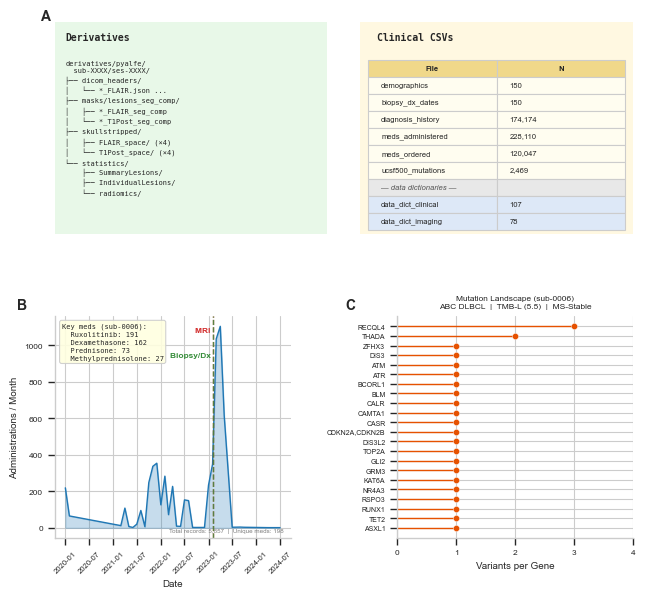

In [9]:
# ============================================================
# Generate Figure 1 (2-row: directory structure + clinical/genomic)
# Sized for single-column (6.5 in wide)
# ============================================================

fig = plt.figure(figsize=(6.5, 6.0), facecolor="white")

gs = gridspec.GridSpec(
    2, 1, height_ratios=[1.1, 1.15],
    hspace=0.38, top=0.96, bottom=0.10, left=0.08, right=0.97,
)

# ────────────────────────────────────────────────────────────
# Panel A — Dataset Structure Schematic
# ────────────────────────────────────────────────────────────
gs_a = gs[0].subgridspec(1, 2, wspace=0.12)

# A-left: Derivatives tree (light green)
ax_a1 = fig.add_subplot(gs_a[0])
ax_a1.set_facecolor("#e8f8e8")
deriv_tree = (
    "derivatives/pyalfe/\n"
    "  sub-XXXX/ses-XXXX/\n"
    "├── dicom_headers/\n"
    "│   └── *_FLAIR.json ...\n"
    "├── masks/lesions_seg_comp/\n"
    "│   ├── *_FLAIR_seg_comp\n"
    "│   └── *_T1Post_seg_comp\n"
    "├── skullstripped/\n"
    "│   ├── FLAIR_space/ (×4)\n"
    "│   └── T1Post_space/ (×4)\n"
    "└── statistics/\n"
    "    ├── SummaryLesions/\n"
    "    ├── IndividualLesions/\n"
    "    └── radiomics/"
)
ax_a1.text(
    0.04, 0.95, "Derivatives", fontsize=7,
    fontweight="bold", va="top", family="monospace",
    transform=ax_a1.transAxes,
)
ax_a1.text(
    0.04, 0.82, deriv_tree, fontsize=5, va="top",
    family="monospace", linespacing=1.3, transform=ax_a1.transAxes,
)
ax_a1.set_xticks([]); ax_a1.set_yticks([])
for sp in ax_a1.spines.values():
    sp.set_visible(False)
ax_a1.text(
    -0.05, 1.06, "A", fontsize=10, fontweight="bold",
    va="top", transform=ax_a1.transAxes,
)

# A-right: Clinical CSV table (light amber)
ax_a2 = fig.add_subplot(gs_a[1])
ax_a2.set_facecolor("#fff8e1")
ax_a2.text(
    0.06, 0.95, "Clinical CSVs", fontsize=7,
    fontweight="bold", va="top", family="monospace",
    transform=ax_a2.transAxes,
)
# Shorten filenames for table readability
csv_display = [
    ("demographics",         csv_info["demographics"]),
    ("biopsy_dx_dates",       csv_info["biopsy_and_diagnosis_dates"]),
    ("diagnosis_history",     csv_info["diagnosis_history"]),
    ("meds_administered",     csv_info["medication_list_administered"]),
    ("meds_ordered",          csv_info["medication_list_ordered"]),
    ("ucsf500_mutations",     csv_info["ucsf500_mutations"]),
    (None, None),  # separator
    ("data_dict_clinical",    dd_info["data_dictionary_clinical"]),
    ("data_dict_imaging",     dd_info["data_dictionary_imaging"]),
]
tbl_rows = [[name if name else "— data dictionaries —",
             f"{n:,}" if n is not None else ""]
            for name, n in csv_display]
tbl = ax_a2.table(
    cellText=tbl_rows,
    colLabels=["File", "N"],
    cellLoc="left",
    bbox=[0.03, 0.02, 0.94, 0.80],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(5.5)
# Row indices: 0=header, 1-6=clinical CSVs, 7=separator, 8-9=data dicts
SEPARATOR_ROW = 7  # 0-indexed table row (after header)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if r == 0:
        cell.set_facecolor("#f0d88a")
        cell.set_text_props(fontweight="bold")
    elif r == SEPARATOR_ROW:
        cell.set_facecolor("#e8e8e8")
        cell.set_text_props(style="italic", color="#555555")
    elif r > SEPARATOR_ROW:
        cell.set_facecolor("#dde8f7")  # light blue for data dicts
    else:
        cell.set_facecolor("#fffdf0")
ax_a2.set_xticks([]); ax_a2.set_yticks([])
for sp in ax_a2.spines.values():
    sp.set_visible(False)

# ────────────────────────────────────────────────────────────
# Panel B — Medication Timeline (sub-0006) with key meds
# ────────────────────────────────────────────────────────────
gs_bc = gs[1].subgridspec(1, 2, wspace=0.45)
ax_b = fig.add_subplot(gs_bc[0])

mp = df_meds_sub6.copy()
mp["dt"] = pd.to_datetime(mp["AdministrationInstant"], errors="coerce")
mp = mp.dropna(subset=["dt"])
mp["ym"] = mp["dt"].dt.to_period("M")
monthly = mp.groupby("ym").size()
monthly.index = monthly.index.to_timestamp()

ax_b.fill_between(monthly.index, monthly.values, alpha=0.25, color="#1f77b4")
ax_b.plot(monthly.index, monthly.values, color="#1f77b4", lw=1.0)
ax_b.set_xlabel("Date", fontsize=7)
ax_b.set_ylabel("Administrations / Month", fontsize=7)
ax_b.tick_params(axis="y", labelsize=6)
ax_b.tick_params(axis="x", labelsize=5.5, rotation=45)
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)

# Event markers: MRI (2/2/23), Biopsy/Diagnosis (2/7/23)
mri_date = pd.Timestamp("2023-02-02")
biopsy_date = pd.Timestamp("2023-02-07")
ax_b.axvline(mri_date, color="#d32f2f", ls="--", lw=1.0, alpha=0.8)
ax_b.axvline(biopsy_date, color="#388e3c", ls="--", lw=1.0, alpha=0.8)
ylim = ax_b.get_ylim()
ax_b.text(
    mri_date, ylim[1] * 0.95, "MRI ", fontsize=6, color="#d32f2f",
    va="top", ha="right", fontweight="bold",
)
ax_b.text(
    biopsy_date, ylim[1] * 0.83, "Biopsy/Dx ", fontsize=6, color="#388e3c",
    va="top", ha="right", fontweight="bold",
)

# --- Key PCNSL-relevant medications (grouped by class) ---
med_name_lower = mp["MedicationGenericName"].str.lower()

drug_classes = {
    "Ruxolitinib":        med_name_lower.str.contains("ruxolitinib", na=False),
    "Dexamethasone":      med_name_lower.str.contains("dexamethasone", na=False),
    "Prednisone":         med_name_lower.str.contains("prednisone", na=False) & ~med_name_lower.str.contains("methyl", na=False),
    "Methylprednisolone": med_name_lower.str.contains("methylprednisolone", na=False),
}

med_lines = []
for label, mask in drug_classes.items():
    n = mask.sum()
    if n > 0:
        med_lines.append(f"{label}: {n}")

med_text = "Key meds (sub-0006):\n" + "\n".join(f"  {l}" for l in med_lines)

ax_b.text(
    0.03, 0.97, med_text,
    transform=ax_b.transAxes, fontsize=5, va="top", ha="left",
    family="monospace", linespacing=1.4,
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.9,
              edgecolor="#cccccc"),
)

# Summary inset (bottom-right)
n_unique = mp["MedicationGenericName"].nunique()
ax_b.text(
    0.97, 0.02,
    f"Total records: {len(mp):,}  |  Unique meds: {n_unique}",
    transform=ax_b.transAxes, fontsize=4.5, va="bottom", ha="right",
    color="gray",
)
ax_b.text(
    -0.16, 1.08, "B", fontsize=10, fontweight="bold",
    va="top", transform=ax_b.transAxes,
)

# ────────────────────────────────────────────────────────────
# Panel C — Mutation Lollipop Chart (sub-0006)
# ────────────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs_bc[1])

gene_cts = df_mut_sub6.groupby("gene").size().sort_values(ascending=True)
ypos = np.arange(len(gene_cts))

ax_c.hlines(ypos, 0, gene_cts.values, color="#e65100", lw=1.0, zorder=2)
ax_c.scatter(
    gene_cts.values, ypos, color="#e65100", s=20, zorder=3,
    edgecolors="white", linewidths=0.3,
)
ax_c.set_yticks(ypos)
ax_c.set_yticklabels(gene_cts.index, fontsize=5)
ax_c.set_xlabel("Variants per Gene", fontsize=7)
ax_c.tick_params(axis="x", labelsize=6)
ax_c.spines["top"].set_visible(False)
ax_c.spines["right"].set_visible(False)
ax_c.set_xlim(left=0)
ax_c.set_xticks(range(0, int(gene_cts.max()) + 2))

# Header: ABC DLBCL | TMB-L (5.5) | MS-Stable
r0 = df_mut_sub6.iloc[0]
header = f"ABC DLBCL  |  TMB-L ({r0['tmbscore']})  |  {r0['microsatellitestatus']}"
ax_c.set_title(
    f"Mutation Landscape (sub-0006)\n{header}",
    fontsize=6, pad=6,
)
ax_c.text(
    -0.22, 1.08, "C", fontsize=10, fontweight="bold",
    va="top", transform=ax_c.transAxes,
)

# ────────────────────────────────────────────────────────────
# Save
# ────────────────────────────────────────────────────────────

for _ext in ("png", "pdf", "eps"):
    fig.savefig(
        f"fig1_data_overview.{_ext}",
        dpi=1200, bbox_inches="tight", facecolor="white",
    )
print("Saved: outputs/fig1_data_overview.{png, pdf, eps}")
plt.show()

Saved: outputs/fig_selection_flowchart.{png, pdf, eps}


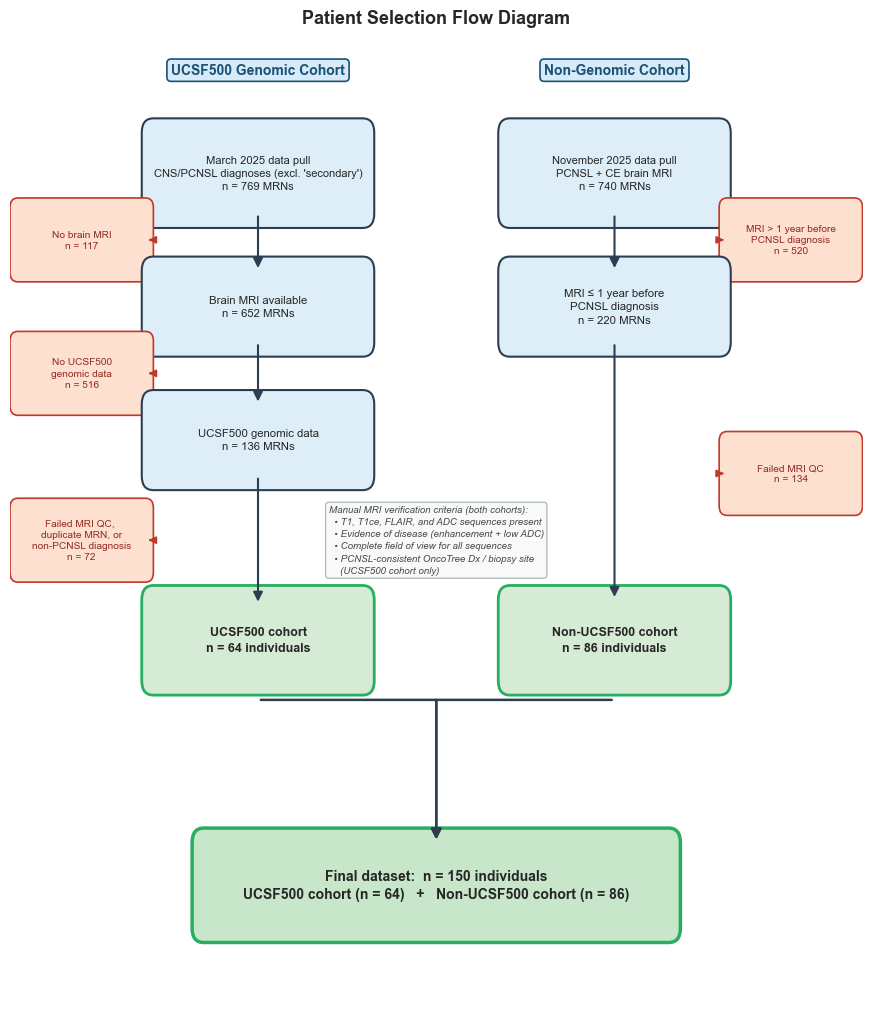

In [10]:
# ============================================================
# Figure: Patient selection flow diagram (CONSORT-style)
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

fig, ax = plt.subplots(figsize=(11, 13))
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.0, 1.05)
ax.axis('off')

# ── Palette ──────────────────────────────────────────────────────────
C_MAIN  = "#ddeef8"
C_FINAL = "#d5ebd5"
C_MERGE = "#c8e6c9"
C_EXCL  = "#fde0d0"
EC      = "#2c3e50"
EC_EX   = "#c0392b"
EC_FIN  = "#27ae60"

LX, RX = 0.27, 0.73   # column centres
BW = 0.27              # main box width
H_TALL, H_NORM = 0.085, 0.075
EW, EH = 0.165, 0.068  # exclusion box dims

# ── Helpers ───────────────────────────────────────────────────────────
def draw_box(cx, cy, w, h, text, fc=C_MAIN, ec=EC, fs=8.2, fw='normal', lw=1.5):
    ax.add_patch(FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.015",
        facecolor=fc, edgecolor=ec, linewidth=lw, zorder=2))
    ax.text(cx, cy, text, ha='center', va='center', fontsize=fs,
            fontweight=fw, multialignment='center', linespacing=1.4, zorder=3)

def arrow_down(cx, y_top, y_bot, h_top=H_NORM, h_bot=H_NORM):
    ax.annotate('', xy=(cx, y_bot + h_bot/2), xytext=(cx, y_top - h_top/2),
                arrowprops=dict(arrowstyle='-|>', color=EC, lw=1.5,
                                mutation_scale=14))

def draw_excl(cx, cy, bw, text, side='left'):
    """Exclusion box branching off the side of the main column."""
    stub = cx - bw/2 if side == 'left' else cx + bw/2
    ex_cx = stub - 0.01 - EW/2 if side == 'left' else stub + 0.01 + EW/2
    tip   = ex_cx + EW/2 if side == 'left' else ex_cx - EW/2
    ax.annotate('', xy=(tip, cy), xytext=(stub, cy),
                arrowprops=dict(arrowstyle='-|>', color=EC_EX, lw=1.2,
                                mutation_scale=11))
    ax.add_patch(FancyBboxPatch(
        (ex_cx - EW/2, cy - EH/2), EW, EH,
        boxstyle="round,pad=0.01",
        facecolor=C_EXCL, edgecolor=EC_EX, linewidth=1.2, zorder=2))
    ax.text(ex_cx, cy, text, ha='center', va='center', fontsize=7.3,
            color='#922b21', multialignment='center', linespacing=1.3, zorder=3)

def arrow_to_merge(from_cx, from_cy, to_cx, to_cy, h_from=H_TALL, h_to=0.09):
    ax.annotate('', xy=(to_cx, to_cy + h_to/2),
                xytext=(from_cx, from_cy - h_from/2),
                arrowprops=dict(
                    arrowstyle='-|>', color=EC, lw=1.8, mutation_scale=15,
                    connectionstyle='angle,angleA=0,angleB=90,rad=0.02'))

# ══════════════════════════════════════════════════════════════════════
#  COLUMN HEADERS
# ══════════════════════════════════════════════════════════════════════
for cx, label in [(LX, "UCSF500 Genomic Cohort"), (RX, "Non-Genomic Cohort")]:
    ax.text(cx, 0.990, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='#1a5276',
            bbox=dict(boxstyle='round,pad=0.3', fc='#d6eaf8',
                      ec='#1a5276', lw=1.2))

# ══════════════════════════════════════════════════════════════════════
#  LEFT COLUMN — March 2025 pull (UCSF500)
# ══════════════════════════════════════════════════════════════════════
LY1, LY2, LY3, LY4 = 0.882, 0.742, 0.602, 0.392

draw_box(LX, LY1, BW, H_TALL,
         "March 2025 data pull\n"
         "CNS/PCNSL diagnoses (excl. 'secondary')\n"
         "n = 769 MRNs", fs=8)

arrow_down(LX, LY1, LY2, h_top=H_TALL)
draw_excl(LX, (LY1 + LY2)/2, BW, "No brain MRI\nn = 117", side='left')

draw_box(LX, LY2, BW, H_NORM,
         "Brain MRI available\nn = 652 MRNs")

arrow_down(LX, LY2, LY3)
draw_excl(LX, (LY2 + LY3)/2, BW, "No UCSF500\ngenomic data\nn = 516", side='left')

draw_box(LX, LY3, BW, H_NORM,
         "UCSF500 genomic data\nn = 136 MRNs")

arrow_down(LX, LY3, LY4)
draw_excl(LX, (LY3 + LY4)/2, BW,
          "Failed MRI QC, \nduplicate MRN, or\nnon-PCNSL diagnosis\nn = 72", side='left')

draw_box(LX, LY4, BW, H_TALL,
         "UCSF500 cohort\nn = 64 individuals",
         fc=C_FINAL, ec=EC_FIN, fw='bold', lw=2.0, fs=9)

# ══════════════════════════════════════════════════════════════════════
#  RIGHT COLUMN — November 2025 pull (no genomics)
# ══════════════════════════════════════════════════════════════════════
RY1, RY2, RY3 = 0.882, 0.742, 0.392

draw_box(RX, RY1, BW, H_TALL,
         "November 2025 data pull\n"
         "PCNSL + CE brain MRI\n"
         "n = 740 MRNs", fs=8)

arrow_down(RX, RY1, RY2, h_top=H_TALL)
draw_excl(RX, (RY1 + RY2)/2, BW,
          "MRI > 1 year before\nPCNSL diagnosis\nn = 520", side='right')

draw_box(RX, RY2, BW, H_NORM,
         "MRI ≤ 1 year before\nPCNSL diagnosis\nn = 220 MRNs")

arrow_down(RX, RY2, RY3, h_bot=H_TALL)
draw_excl(RX, (RY2 + RY3)/2, BW,
          "Failed MRI QC\nn = 134", side='right')

draw_box(RX, RY3, BW, H_TALL,
         "Non-UCSF500 cohort\nn = 86 individuals",
         fc=C_FINAL, ec=EC_FIN, fw='bold', lw=2.0, fs=9)

# ══════════════════════════════════════════════════════════════════════
#  MRI QC CRITERIA NOTE (centre, between the two lower exclusion arrows)
# ══════════════════════════════════════════════════════════════════════
qc_note_y = (LY3 + LY4) / 2   # vertically between 3rd and 4th left boxes
ax.text(0.50, qc_note_y,
        "Manual MRI verification criteria (both cohorts):\n"
        "  • T1, T1ce, FLAIR, and ADC sequences present\n"
        "  • Evidence of disease (enhancement + low ADC)\n"
        "  • Complete field of view for all sequences\n"
        "  • PCNSL-consistent OncoTree Dx / biopsy site\n"
        "    (UCSF500 cohort only)",
        ha='center', va='center', fontsize=7.0,
        multialignment='left', linespacing=1.45,
        style='italic', color='#4a4a4a',
        bbox=dict(boxstyle='round,pad=0.32', fc='#f8f9fa',
                  ec='#aab7b8', lw=0.9))

# ══════════════════════════════════════════════════════════════════════
#  FINAL MERGED BOX
# ══════════════════════════════════════════════════════════════════════
FY = 0.135
arrow_to_merge(LX, LY4-.02, 0.50, FY)
arrow_to_merge(RX, RY3-.02, 0.50, FY)

draw_box(0.50, FY, 0.60, 0.09,
         "Final dataset:  n = 150 individuals\n"
         "UCSF500 cohort (n = 64)   +   Non-UCSF500 cohort (n = 86)",
         fc=C_MERGE, ec=EC_FIN, fw='bold', lw=2.5, fs=10)

# ══════════════════════════════════════════════════════════════════════
#  Title
# ══════════════════════════════════════════════════════════════════════
ax.text(0.50, 1.035, "Patient Selection Flow Diagram",
        ha='center', va='bottom', fontsize=13, fontweight='bold')


for _ext in ("png", "pdf", "eps"):
    fig.savefig(f"fig_selection_flowchart.{_ext}",
                dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: outputs/fig_selection_flowchart.{png, pdf, eps}")
plt.show()


In [11]:
import sys
import pandas as pd
from pathlib import Path
sys.path.insert(0, "/Users/mromano/research/UCSF-PCNSL")
from pcnsl_data_loader import load_aws_dicom_headers

dicom_df = load_aws_dicom_headers()

# sequence column is already set by load_aws_dicom_headers
# Move key columns to front
front_cols = ["subject", "session", "sequence"]
other_cols = [c for c in dicom_df.columns if c not in front_cols]
dicom_df = dicom_df[front_cols + other_cols]

print(f"Loaded {len(dicom_df)} records across {dicom_df['subject'].nunique()} subjects")
print(f"Sequences: {dicom_df['sequence'].value_counts().to_dict()}")
print(f"Columns ({len(dicom_df.columns)}): {list(dicom_df.columns)}")
dicom_df.head()

Loaded 600 records across 150 subjects
Sequences: {'DWI_ADC': 150, 'FLAIR': 150, 'T1w': 150, 'ce-gadolinium_T1w': 150}
Columns (80): ['subject', 'session', 'sequence', 'Modality', 'MagneticFieldStrength', 'ImagingFrequency', 'Manufacturer', 'ManufacturersModelName', 'StationName', 'PatientPosition', 'SoftwareVersions', 'MRAcquisitionType', 'StudyDescription', 'SeriesDescription', 'ProtocolName', 'ScanningSequence', 'SequenceVariant', 'ScanOptions', 'PulseSequenceName', 'ImageType', 'RawImage', 'DeidentificationMethod', 'DeidentificationMethodCodeSequence', 'SeriesNumber', 'AcquisitionTime', 'SliceThickness', 'SpacingBetweenSlices', 'EchoTime', 'RepetitionTime', 'FlipAngle', 'NumberOfDiffusionT2GE', 'CoilString', 'NumberOfExcitations', 'AcquisitionMatrixPE', 'ReconMatrixPE', 'ParallelReductionFactorInPlane', 'AcquisitionDuration', 'PixelBandwidth', 'PhaseEncodingAxis', 'ImageOrientationPatientDICOM', 'InPlanePhaseEncodingDirectionDICOM', 'BidsGuess', 'ConversionSoftware', 'ConversionSof

,subject,session,sequence,Modality,MagneticFieldStrength,ImagingFrequency,Manufacturer,ManufacturersModelName,StationName,PatientPosition,...,PhilipsRWVIntercept,MTState,PartialFourierDirection,PartialFourierEnabled,PhaseEncodingStepsNoPartialFourier,FrequencyEncodingSteps,PhaseEncodingStepsOutOfPlane,ParallelAcquisitionTechnique,Units,DiffGradientCyclingGE
0,sub-0001,ses-0001,DWI_ADC,MR,1.5,63.864063,GE,Signa HDxt,Deid-Validation,HFS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sub-0001,ses-0001,FLAIR,MR,1.5,63.864059,GE,Signa HDxt,Deid-Validation,HFS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sub-0001,ses-0001,T1w,MR,1.5,63.864059,GE,Signa HDxt,Deid-Validation,HFS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sub-0001,ses-0001,ce-gadolinium_T1w,MR,1.5,63.864059,GE,Signa HDxt,Deid-Validation,HFS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-0002,ses-0001,DWI_ADC,NaN,3.0,127.742274,GE,DISCOVERY MR750,NaN,HFS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
if dicom_df.empty:
    print("Skipping acquisition parameter table: no scanner data available.")
    gt = None
else:
    import numpy as np
    import pandas as pd
    from great_tables import GT, style, loc, md

    df_tbl = dicom_df.copy()

    # ── Parameters and display labels ────────────────────────────────────────────
    # TR/TE/TI are in ms (load_aws_dicom_headers converts from dcm2niix seconds to ms)
    PARAMS = {
        "RepetitionTime": "TR (ms)",
        "EchoTime":       "TE (ms)",
        "FlipAngle":      "Flip Angle (°)",
        "InversionTime":  "TI (ms)",
        "SliceThickness": "Slice Thickness (mm)",
    }

    seq_order = sorted(df_tbl["sequence"].unique())
    n_total   = df_tbl["sequence"].value_counts()

    # ── Build continuous-parameter rows ───────────────────────────────────────────
    rows = []
    pct_missing_matrix = {}

    for col, label in PARAMS.items():
        row = {"Parameter": label}
        pct_missing_matrix[label] = {}

        for seq in seq_order:
            n_seq = n_total.get(seq, 0)
            if col in df_tbl.columns:
                sub = pd.to_numeric(df_tbl.loc[df_tbl["sequence"] == seq, col], errors="coerce")
            else:
                sub = pd.Series(dtype=float)
            n_valid   = sub.notna().sum()
            n_missing = n_seq - n_valid
            pct_miss  = 100 * n_missing / n_seq if n_seq > 0 else 100.0
            pct_missing_matrix[label][seq] = pct_miss

            if n_valid == 0:
                cell_val = "—"
            else:
                val_str  = f"{sub.mean():.1f} ± {sub.std():.1f}"
                miss_str = f"({n_missing}/{n_seq} missing, {pct_miss:.0f}%)" if n_missing > 0 else f"(n={n_valid})"
                cell_val = val_str + "\n" + miss_str

            row[seq] = cell_val

        rows.append(row)

    # ── Field strength rows ────────────────────────────────────────────────────────
    for target_T, fs_label in [(1.5, "Field Strength 1.5 T, n (%)"),
                               (3.0, "Field Strength 3 T, n (%)")]:
        row = {"Parameter": fs_label}
        pct_missing_matrix[fs_label] = {}

        for seq in seq_order:
            n_seq = n_total.get(seq, 0)
            fs = pd.to_numeric(df_tbl.loc[df_tbl["sequence"] == seq, "MagneticFieldStrength"], errors="coerce")
            n_missing = fs.isna().sum()
            pct_miss  = 100 * n_missing / n_seq if n_seq > 0 else 100.0
            pct_missing_matrix[fs_label][seq] = pct_miss

            n_match = (fs.round(1) == target_T).sum()
            pct     = 100 * n_match / (n_seq - n_missing) if (n_seq - n_missing) > 0 else 0.0
            miss_str = "\n(" + str(n_missing) + "/" + str(n_seq) + " missing)" if n_missing > 0 else ""
            row[seq] = f"{n_match} ({pct:.0f}%)" + miss_str

        rows.append(row)

    summary_df = pd.DataFrame(rows)

    col_labels = {
        seq: seq.replace("ce-gadolinium_T1w", "T1w (CE)").replace("_", " ")
        for seq in seq_order
    }

    gt = (
        GT(summary_df, rowname_col="Parameter")
        .tab_header(
            title="MRI Acquisition Parameters by Sequence",
            subtitle="Continuous values: mean ± SD. Field strength: count (% of scans with known field strength). "
                     + "N per sequence: "
                     + ", ".join(f"{col_labels[s]}={n_total.get(s, 0)}" for s in seq_order),
        )
        .cols_label(**{seq: md(col_labels[seq]) for seq in seq_order})
        .tab_source_note(
            md("TR = repetition time, TE = echo time, TI = inversion time (all in **ms**). "
               "Values from dcm2niix BIDS sidecars (converted from seconds). "
               "For FOV/Matrix see per-subject table (derived from raw DICOM pixel geometry). "
               "**Amber** = any missing data; **Red** = >50% missing.")
        )
        .opt_horizontal_padding(scale=2)
        .opt_vertical_padding(scale=1.5)
        .tab_style(style=style.text(weight="bold"), locations=loc.column_labels())
        .tab_style(style=style.text(style="italic"), locations=loc.stub())
    )

    for seq in seq_order:
        for param_label, pct in pct_missing_matrix.items():
            p = pct[seq]
            if p > 50:
                gt = gt.tab_style(
                    style=style.fill(color="#FFCCCC"),
                    locations=loc.body(columns=seq, rows=[param_label]),
                )
            elif p > 0:
                gt = gt.tab_style(
                    style=style.fill(color="#FFF3CD"),
                    locations=loc.body(columns=seq, rows=[param_label]),
                )

    gt


In [ ]:
import pandas as pd
from pathlib import Path
from great_tables import GT, style, loc, md

if dicom_df is None or dicom_df.empty:
    print("Skipping per-subject table: no DICOM data available.")
    gt2 = None
else:
    SEQ_ORDER  = ["FLAIR", "T1w", "ce-gadolinium_T1w", "DWI_ADC"]
    SEQ_LABELS = {"FLAIR": "FLAIR", "T1w": "T1w",
                  "ce-gadolinium_T1w": "T1w (CE)", "DWI_ADC": "DWI / ADC"}
    SEQ_FIELDS = {"MRAcquisitionType": "Acq. Type"}

    df_ind = dicom_df.copy()
    df_ind["MagneticFieldStrength"] = pd.to_numeric(
        df_ind["MagneticFieldStrength"], errors="coerce"
    ).apply(lambda x: f"{x:g} T" if pd.notna(x) else "—")

    def _scanner(r):
        parts = [r.get("Manufacturer"), r.get("ManufacturersModelName")]
        s = " ".join(str(p) for p in parts if pd.notna(p) and str(p).strip())
        return s or "—"
    df_ind["Scanner"] = df_ind.apply(_scanner, axis=1)

    subjects = sorted(df_ind["subject"].unique())
    rows = []

    for subj in subjects:
        row = {"Subject": subj}
        df_subj = df_ind[df_ind["subject"] == subj]

        # Scanner and MagneticFieldStrength are always non-null strings after the transforms above
        row["Scanner"]               = df_subj["Scanner"].iloc[0]
        row["MagneticFieldStrength"] = df_subj["MagneticFieldStrength"].iloc[0]

        for seq in SEQ_ORDER:
            df_seq = df_subj[df_subj["sequence"] == seq]
            for raw_col in SEQ_FIELDS:
                col_name = f"{seq}__{raw_col}"
                if df_seq.empty or raw_col not in df_seq.columns:
                    row[col_name] = "—"
                else:
                    val = df_seq[raw_col].iloc[0]
                    row[col_name] = str(val).strip() if pd.notna(val) and str(val).strip() else "—"

        rows.append(row)

    seq_cols = [f"{seq}__{raw}" for seq in SEQ_ORDER for raw in SEQ_FIELDS]
    wide_df  = pd.DataFrame(rows)[["Subject", "Scanner", "MagneticFieldStrength"] + seq_cols]

    gt2 = (
        GT(wide_df, rowname_col="Subject")
        .tab_header(
            title="Per-Subject Scanner Information",
            subtitle=f"N = {len(subjects)} subjects.",
        )
        .cols_label(Scanner="Scanner", MagneticFieldStrength="Field (T)")
    )

    for seq in SEQ_ORDER:
        rename_map = {f"{seq}__{raw}": label for raw, label in SEQ_FIELDS.items()}
        gt2 = (
            gt2
            .cols_label(**rename_map)
            .tab_spanner(label=SEQ_LABELS[seq], columns=list(rename_map.keys()))
        )

    gt2 = (
        gt2
        .tab_source_note(
            md("Scanner = Manufacturer + Model. Field strength in Tesla (dcm2niix BIDS sidecar). "
               "— = file absent or field missing.")
        )
        .opt_horizontal_padding(scale=1.5)
        .opt_vertical_padding(scale=1.0)
        .tab_style(style=style.text(weight="bold"), locations=loc.column_labels())
        .tab_style(style=style.text(size="11px"), locations=loc.body())
    )

    for i, subj in enumerate(subjects):
        if i % 2 == 0:
            gt2 = gt2.tab_style(
                style=style.fill(color="#F8F8F8"),
                locations=loc.body(rows=[subj]),
            )

    gt2


In [ ]:
from pathlib import Path

_out = Path(".")

if gt is not None:
    with open(_out / "table_acquisition_params.html", "w") as f:
        f.write(gt.as_raw_html())
    print(f"Saved → {_out}/table_acquisition_params.html")
else:
    print("Skipping table_acquisition_params.html: no scanner data available.")

if gt2 is not None:
    with open(_out / "table_scanner_info_per_subject.html", "w") as f:
        f.write(gt2.as_raw_html())
    print(f"Saved → {_out}/table_scanner_info_per_subject.html")
else:
    print("Skipping table_scanner_info_per_subject.html: no scanner data available.")

print("\nTo import into Word: File → Open the .html file directly, or open in a")
print("browser, select all (Cmd+A), copy (Cmd+C), and paste into your document.")


In [ ]:
import sys
import pandas as pd
import numpy as np
from great_tables import GT, style, loc, md
sys.path.insert(0, "/Users/mromano/research/UCSF-PCNSL")
from pcnsl_data_loader import load_aws_dicom_geometry

geom_df = load_aws_dicom_geometry()

print(f"Loaded {len(geom_df)} records across {geom_df['subject'].nunique()} subjects")
print(f"Sequences: {geom_df['sequence'].value_counts().to_dict()}")

SEQ_ORDER = ["FLAIR", "T1w", "ce-gadolinium_T1w", "DWI_ADC"]
SEQ_LABELS = {
    "FLAIR":             "FLAIR",
    "T1w":               "T1w",
    "ce-gadolinium_T1w": "T1w (CE)",
    "DWI_ADC":           "DWI / ADC",
}

seq_order  = [s for s in SEQ_ORDER if s in geom_df["sequence"].unique()]
n_total    = geom_df["sequence"].value_counts()
seq_groups = {seq: geom_df[geom_df["sequence"] == seq] for seq in seq_order}

rows = []
pct_missing_matrix = {}

# ── Acquisition type row (categorical: % 2D / % 3D) ──────────────────────────
label = "Acquisition Type"
row = {"Parameter": label}
pct_missing_matrix[label] = {}
for seq in seq_order:
    sub   = seq_groups[seq]["MRAcquisitionType"]
    n_seq = n_total.get(seq, 0)
    n_missing = sub.isna().sum()
    pct_missing_matrix[label][seq] = 100 * n_missing / n_seq if n_seq > 0 else 100.0
    if sub.notna().sum() == 0:
        row[seq] = "—"
    else:
        vc = sub.dropna().value_counts()
        row[seq] = ", ".join(f"{v}: {c} ({100*c/n_seq:.0f}%)" for v, c in vc.items())
rows.append(row)

# ── Continuous geometry parameters ───────────────────────────────────────────
CONT_PARAMS = [
    ("PixelSpacing_mm",  "In-plane pixel spacing (mm)"),
    ("SliceThickness",   "Slice thickness (mm)"),
    ("SliceGap_mm",      "Slice gap/overlap (mm)"),
    ("FOV_row_mm",       "FOV (mm)"),
    ("NumSlices",        "No. slices"),
    ("VoxelVolume_mm3",  "Voxel volume (mm³)"),
]

for col, label in CONT_PARAMS:
    row = {"Parameter": label}
    pct_missing_matrix[label] = {}
    for seq in seq_order:
        n_seq = n_total.get(seq, 0)

        # SliceGap is only meaningful for 2D acquisitions — filter to 2D only
        if col == "SliceGap_mm" and "MRAcquisitionType" in geom_df.columns:
            grp = seq_groups[seq]
            mask_2d = grp["MRAcquisitionType"] == "2D"
            n_2d = mask_2d.sum()
            if n_2d == 0:
                pct_missing_matrix[label][seq] = 0.0
                row[seq] = "N/A (3D)"
                continue
            sub = pd.to_numeric(grp.loc[mask_2d, col], errors="coerce")
            n_valid   = sub.notna().sum()
            n_missing = n_2d - n_valid
            pct_missing_matrix[label][seq] = 100 * n_missing / n_2d
            if n_valid == 0:
                row[seq] = "—"
            else:
                val_str  = f"{sub.mean():.2f} ± {sub.std():.2f}"
                miss_str = f"({n_missing}/{n_2d} 2D missing)" if n_missing > 0 else f"(n={n_valid} 2D)"
                row[seq] = val_str + "\n" + miss_str
            continue

        if col not in geom_df.columns:
            sub = pd.Series(dtype=float)
        else:
            sub = pd.to_numeric(seq_groups[seq][col], errors="coerce")
        n_valid   = sub.notna().sum()
        n_missing = n_seq - n_valid
        pct_missing_matrix[label][seq] = 100 * n_missing / n_seq if n_seq > 0 else 100.0
        if n_valid == 0:
            row[seq] = "—"
        else:
            val_str  = f"{sub.mean():.2f} ± {sub.std():.2f}"
            miss_str = f"({n_missing}/{n_seq} missing)" if n_missing > 0 else f"(n={n_valid})"
            row[seq] = val_str + "\n" + miss_str
    rows.append(row)

# ── Matrix row (categorical) ──────────────────────────────────────────────────
label = "Matrix"
row = {"Parameter": label}
pct_missing_matrix[label] = {}
for seq in seq_order:
    n_seq = n_total.get(seq, 0)
    if "Matrix" not in geom_df.columns:
        sub = pd.Series(dtype=str)
    else:
        sub = seq_groups[seq]["Matrix"].dropna()
    n_missing = n_seq - len(sub)
    pct_missing_matrix[label][seq] = 100 * n_missing / n_seq if n_seq > 0 else 100.0
    if len(sub) == 0:
        row[seq] = "—"
    else:
        top = sub.value_counts()
        row[seq] = ", ".join(f"{v} (n={c})" for v, c in top.items())
rows.append(row)

geom_summary_df = pd.DataFrame(rows)

gt_geom = (
    GT(geom_summary_df, rowname_col="Parameter")
    .tab_header(
        title="MRI Acquisition Geometry by Sequence",
        subtitle="Continuous values: mean ± SD. "
                 + "N per sequence: "
                 + ", ".join(f"{SEQ_LABELS[s]}={n_total.get(s, 0)}" for s in seq_order),
    )
    .cols_label(**{seq: md(SEQ_LABELS[seq]) for seq in seq_order})
    .tab_source_note(
        md("In-plane pixel spacing: row component of PixelSpacing tag (mm). "
           "Slice gap/overlap = SpacingBetweenSlices − SliceThickness "
           "(negative = 3D slice overlap; positive = 2D slice gap; 0 = contiguous); "
           "reported only for 2D acquisitions — N/A (3D) where all scans are 3D. "
           "FOV = Rows × PixelSpacing. Voxel volume = PixelSpacing² × SliceThickness. "
           "Derived from raw DICOM headers. "
           "**Amber** = any missing data; **Red** = >50% missing.")
    )
    .opt_horizontal_padding(scale=2)
    .opt_vertical_padding(scale=1.5)
    .tab_style(style=style.text(weight="bold"), locations=loc.column_labels())
    .tab_style(style=style.text(style="italic"), locations=loc.stub())
)

for seq in seq_order:
    for param_label, pct in pct_missing_matrix.items():
        p = pct[seq]
        if p > 50:
            gt_geom = gt_geom.tab_style(
                style=style.fill(color="#FFCCCC"),
                locations=loc.body(columns=seq, rows=[param_label]),
            )
        elif p > 0:
            gt_geom = gt_geom.tab_style(
                style=style.fill(color="#FFF3CD"),
                locations=loc.body(columns=seq, rows=[param_label]),
            )

with open("table_geometry.html", "w") as f:
    f.write(gt_geom.as_raw_html())
print("Saved → table_geometry.html")

gt_geom
